In [2]:
import pandas as pd
import numpy as np
import arviz as az
import os
import glob
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed

# ===========================
# Part 1: 蒙特卡洛预测函数
# ===========================

# def generate_predictions_for_race(race_df, trace, n_simulations=30000):
#     """为单场比赛生成预测指标"""
#     posterior = trace.posterior
#     n_drivers_in_model = trace.posterior['gamma_driver'].shape[-1]
    
#     alpha = posterior['alpha'].values.flatten()
#     beta_team = posterior['beta_team'].values.reshape(-1, 3)
#     gamma_driver = posterior['gamma_driver'].values.reshape(-1, n_drivers_in_model)
#     eta_grid = posterior['eta_grid'].values.flatten()
#     delta_track = posterior['delta_track'].values.reshape(-1, 3)
#     epsilon_trend = posterior['epsilon_trend'].values.flatten()
#     zeta_dnf = posterior['zeta_dnf'].values.flatten()
#     sigma_race = posterior['sigma_race'].values.flatten()
    
#     n_samples = len(alpha)
#     n_drivers = len(race_df)
    
#     position_counts = np.zeros((n_drivers, n_drivers))
    
#     print(f"    Running {n_simulations:,} Monte Carlo simulations...")
#     for sim in range(n_simulations):
#         if sim % 10000 == 0 and sim > 0:
#             print(f"      Progress: {sim/n_simulations*100:.0f}%", end='\r')
        
#         sample_idx = np.random.randint(0, n_samples)
        
#         predicted_positions = []
#         for idx, row in race_df.iterrows():
#             mu = (
#                 alpha[sample_idx] +
#                 beta_team[sample_idx, int(row['TierCode'])] +
#                 gamma_driver[sample_idx, int(row['DriverIdx'])] +
#                 eta_grid[sample_idx] * row['GridPosition'] +
#                 delta_track[sample_idx, int(row['TrackTypeIdx'])] +
#                 epsilon_trend[sample_idx] * row['Recent5Avg'] +
#                 zeta_dnf[sample_idx] * row['CumDNFRate']
#             )
#             predicted_positions.append(np.random.normal(mu, sigma_race[sample_idx]))
        
#         ranks = np.argsort(predicted_positions) + 1
#         for driver_idx, rank in enumerate(ranks):
#             if 1 <= rank <= n_drivers:
#                 position_counts[driver_idx, rank - 1] += 1
    
#     print(f"      Progress: 100%")
#     position_probs = position_counts / n_simulations
    
#     # 计算各种指标
#     results = []
#     for idx, row in race_df.iterrows():
#         probs = position_probs[idx]
#         expected_pos = np.sum([(i+1) * probs[i] for i in range(n_drivers)])
        
#         cumsum = np.cumsum(probs)
#         median_pos = np.searchsorted(cumsum, 0.5) + 1
#         mode_pos = np.argmax(probs) + 1
        
#         q25 = np.searchsorted(cumsum, 0.25) + 1
#         q75 = np.searchsorted(cumsum, 0.75) + 1
        
#         results.append({
#             'Driver': row['Driver'],
#             'Mode': mode_pos,
#             'Mean': expected_pos,
#             'Median': median_pos,
#             'P_Win': probs[0],
#             'P_Top3': probs[:min(3, n_drivers)].sum(),
#             'P_Top5': probs[:min(5, n_drivers)].sum(),
#             'P_Top10': probs[:min(10, n_drivers)].sum(),
#             'Q25': q25,
#             'Q75': q75,
#             'Entropy': -np.sum(probs[probs > 0] * np.log(probs[probs > 0] + 1e-10)),
#             'ActualRank': row['Position']  # 真实排名
#         })
    
#     return pd.DataFrame(results)
def generate_predictions_for_race(race_df, trace, n_simulations=30000, n_jobs=-1):
    """为单场比赛生成预测指标 (多线程版本)"""
    posterior = trace.posterior
    n_drivers_in_model = trace.posterior['gamma_driver'].shape[-1]
    
    # 提取后验样本
    alpha = posterior['alpha'].values.flatten()
    beta_team = posterior['beta_team'].values.reshape(-1, 3)
    gamma_driver = posterior['gamma_driver'].values.reshape(-1, n_drivers_in_model)
    eta_grid = posterior['eta_grid'].values.flatten()
    delta_track = posterior['delta_track'].values.reshape(-1, 3)
    epsilon_trend = posterior['epsilon_trend'].values.flatten()
    zeta_dnf = posterior['zeta_dnf'].values.flatten()
    sigma_race = posterior['sigma_race'].values.flatten()
    
    n_samples = len(alpha)
    n_drivers = len(race_df)
    
    def run_batch(batch_size):
        """运行一批模拟"""
        batch_counts = np.zeros((n_drivers, n_drivers))
        
        for _ in range(batch_size):
            sample_idx = np.random.randint(0, n_samples)
            
            predicted_positions = []
            for idx, row in race_df.iterrows():
                mu = (
                    alpha[sample_idx] +
                    beta_team[sample_idx, int(row['TierCode'])] +
                    gamma_driver[sample_idx, int(row['DriverIdx'])] +
                    eta_grid[sample_idx] * row['GridPosition'] +
                    delta_track[sample_idx, int(row['TrackTypeIdx'])] +
                    epsilon_trend[sample_idx] * row['Recent5Avg'] +
                    zeta_dnf[sample_idx] * row['CumDNFRate']
                )
                predicted_positions.append(np.random.normal(mu, sigma_race[sample_idx]))
            
            ranks = np.argsort(predicted_positions) + 1
            for driver_idx, rank in enumerate(ranks):
                if 1 <= rank <= n_drivers:
                    batch_counts[driver_idx, rank - 1] += 1
        
        return batch_counts
    
    # 分批并行
    print(f"    Running {n_simulations:,} simulations with {n_jobs} threads...")
    n_cores = n_jobs if n_jobs > 0 else -1
    batch_size = max(1, n_simulations // abs(n_cores) // 4)  # 每批次大小
    n_batches = n_simulations // batch_size
    
    results_list = Parallel(n_jobs=n_jobs)(
        delayed(run_batch)(batch_size) for _ in range(n_batches)
    )
    
    # 合并结果
    position_counts = np.sum(results_list, axis=0)
    position_probs = position_counts / n_simulations
    
    # 计算指标
    results = []
    for idx, row in race_df.iterrows():
        probs = position_probs[idx]
        expected_pos = np.sum([(i+1) * probs[i] for i in range(n_drivers)])
        
        cumsum = np.cumsum(probs)
        median_pos = np.searchsorted(cumsum, 0.5) + 1
        mode_pos = np.argmax(probs) + 1
        q25 = np.searchsorted(cumsum, 0.25) + 1
        q75 = np.searchsorted(cumsum, 0.75) + 1
        
        results.append({
            'Driver': row['Driver'],
            'Mode': mode_pos,
            'Mean': expected_pos,
            'Median': median_pos,
            'P_Win': probs[0],
            'P_Top3': probs[:min(3, n_drivers)].sum(),
            'P_Top5': probs[:min(5, n_drivers)].sum(),
            'P_Top10': probs[:min(10, n_drivers)].sum(),
            'Q25': q25,
            'Q75': q75,
            'Entropy': -np.sum(probs[probs > 0] * np.log(probs[probs > 0] + 1e-10)),
            'ActualRank': row['Position']
        })
    
    return pd.DataFrame(results)


# ===========================
# Part 2: 从缓存文件夹读取比赛数据
# ===========================

def load_race_from_cache(race_folder, race_data_full, driver_to_idx, team_tier_map, track_type_map):
    """
    从单场比赛的缓存文件夹加载数据并准备特征
    """
    race_name = os.path.basename(race_folder)
    
    # 尝试从race_results.csv或其他文件加载
    possible_files = ['race_results.csv', 'race_data.csv', 'results.csv']
    
    race_file = None
    for filename in possible_files:
        filepath = os.path.join(race_folder, filename)
        if os.path.exists(filepath):
            race_file = filepath
            break
    
    if race_file is None:
        # 从race_name解析日期，从race_data_full中获取
        print(f"    No race file found, extracting from race_data_full...")
        date_str = race_name.split('_')[0]
        race_df = race_data_full[race_data_full['Date'] == date_str].copy()
        
        if len(race_df) == 0:
            raise ValueError(f"Cannot find race data for {race_name}")
    else:
        race_df = pd.read_csv(race_file)
    
    # 只保留完赛的车手（Position <= 20）
    if 'Position' in race_df.columns:
        race_df = race_df[race_df['Position'] <= 20].copy()
    
    # 确保有必要的列
    required_base_cols = ['Driver', 'Team', 'GridPosition', 'Position']
    for col in required_base_cols:
        if col not in race_df.columns:
            raise ValueError(f"Missing required column: {col}")
    
    # 重置索引，确保从0开始
    race_df = race_df.reset_index(drop=True)
    
    # 准备特征
    if 'TrackType' not in race_df.columns or 'TrackTypeIdx' not in race_df.columns:
        # 需要从某处获取TrackType
        if 'TrackType' not in race_df.columns:
            print(f"    ⚠️  TrackType missing, using default 'high_speed'")
            race_df['TrackType'] = 'high_speed'
    
    race_df['TrackTypeIdx'] = race_df['TrackType'].map(track_type_map)
    race_df['TierCode'] = race_df['Team'].map(team_tier_map)
    race_df['DriverIdx'] = race_df['Driver'].map(driver_to_idx)
    
    # 过滤无效映射
    valid_mask = (race_df['DriverIdx'].notna() & 
                  race_df['TierCode'].notna() & 
                  race_df['TrackTypeIdx'].notna())
    
    if not valid_mask.all():
        n_invalid = (~valid_mask).sum()
        print(f"    ⚠️  Removing {n_invalid} drivers with invalid mappings")
        race_df = race_df[valid_mask].copy()
    
    # 添加默认的Recent5Avg和CumDNFRate（如果不存在）
    if 'Recent5Avg' not in race_df.columns:
        race_df['Recent5Avg'] = 10.0
    if 'CumDNFRate' not in race_df.columns:
        race_df['CumDNFRate'] = 0.1
    
    # 再次重置索引
    race_df = race_df.reset_index(drop=True)
    
    required_cols = ['Driver', 'GridPosition', 'TierCode', 'DriverIdx', 
                     'TrackTypeIdx', 'Recent5Avg', 'CumDNFRate', 'Position']
    
    return race_df[required_cols]


# ===========================
# Part 3: 批量生成历史预测
# ===========================

def generate_all_historical_predictions(
    cache_dir='f1_cache/2025',
    race_data_csv='data/f1_race_data_cleaned.csv',
    teams_info_csv='data/teams_info.csv',
    trace_file='model/f1_trace.nc',
    output_dir='data/historical_predictions',
    n_simulations=30000
):
    """
    批量为所有历史比赛生成预测数据
    """
    print("="*80)
    print("批量生成历史比赛预测数据")
    print("="*80)
    
    # 加载模型和映射
    print("\n[1/4] 加载模型和数据...")
    race_data_full = pd.read_csv(race_data_csv)
    race_data_full['Date'] = pd.to_datetime(race_data_full['Date']).dt.strftime('%Y-%m-%d')
    
    teams_info = pd.read_csv(teams_info_csv)
    trace = az.from_netcdf(trace_file)
    
    unique_drivers = race_data_full['Driver'].unique()
    driver_to_idx = {driver: idx for idx, driver in enumerate(unique_drivers)}
    team_tier_map = dict(zip(teams_info['Team'], teams_info['Tier']))
    track_type_map = {'high_speed': 0, 'balanced': 1, 'technical': 2}
    
    print(f"  ✅ Loaded {len(unique_drivers)} drivers, {len(teams_info)} teams")
    
    # 查找所有比赛文件夹
    print(f"\n[2/4] 扫描缓存目录: {cache_dir}")
    race_folders = sorted(glob.glob(os.path.join(cache_dir, '2025-*')))
    print(f"  Found {len(race_folders)} race folders")
    
    # 创建输出目录
    os.makedirs(output_dir, exist_ok=True)
    
    # 批量处理
    print(f"\n[3/4] 生成预测数据 (每场 {n_simulations:,} 次模拟)...")
    
    all_predictions = []
    successful = 0
    failed = 0
    
    for i, race_folder in enumerate(race_folders, 1):
        race_name = os.path.basename(race_folder)
        print(f"\n[{i}/{len(race_folders)}] Processing: {race_name}")
        
        try:
            # 加载比赛数据
            race_df = load_race_from_cache(
                race_folder, 
                race_data_full, 
                driver_to_idx, 
                team_tier_map, 
                track_type_map
            )
            
            if len(race_df) == 0:
                print(f"  ❌ No valid drivers found, skipping")
                failed += 1
                continue
            
            # 生成预测
            predictions = generate_predictions_for_race(race_df, trace, n_simulations)
            
            # 添加比赛信息
            predictions['RaceName'] = race_name
            predictions['Date'] = race_name.split('_')[0]
            
            # 保存单场比赛的预测结果
            output_file = os.path.join(race_folder, 'race_predictions.csv')
            predictions.to_csv(output_file, index=False)
            print(f"  ✅ Saved to: {output_file}")
            
            # 添加到汇总列表
            all_predictions.append(predictions)
            successful += 1
            
        except Exception as e:
            print(f"  ❌ Error: {e}")
            failed += 1
            continue
    
    # 合并所有预测
    print(f"\n[4/4] 合并所有预测结果...")
    if all_predictions:
        combined_predictions = pd.concat(all_predictions, ignore_index=True)
        output_file = os.path.join(output_dir, 'all_historical_predictions.csv')
        combined_predictions.to_csv(output_file, index=False)
        print(f"  ✅ 合并文件保存到: {output_file}")
        print(f"  📊 总计: {len(combined_predictions)} 条预测记录")
    else:
        print("  ⚠️  没有成功生成任何预测")
    
    # 统计
    print(f"\n{'='*80}")
    print(f"生成完成统计")
    print(f"{'='*80}")
    print(f"成功: {successful} 场比赛")
    print(f"失败: {failed} 场比赛")
    print(f"总计: {len(race_folders)} 场比赛")
    print(f"{'='*80}\n")
    
    return combined_predictions if all_predictions else None


# ===========================
# Part 4: 简化版 - 直接从race_data_cleaned生成
# ===========================

def generate_predictions_from_cleaned_data(
    race_data_csv='data/f1_race_data_cleaned.csv',
    teams_info_csv='data/teams_info.csv',
    trace_file='model/f1_trace.nc',
    output_file='data/historical_predictions.csv',
    n_simulations=30000,
    start_date=None,
    end_date=None
):
    """
    直接从f1_race_data_cleaned.csv生成历史预测
    这是最简单的方法，不需要FastF1缓存
    """
    print("="*80)
    print("从cleaned data直接生成历史预测")
    print("="*80)
    
    # 加载数据
    print("\n[1/3] 加载数据...")
    race_data = pd.read_csv(race_data_csv)
    teams_info = pd.read_csv(teams_info_csv)
    trace = az.from_netcdf(trace_file)
    
    # 转换日期
    race_data['Date'] = pd.to_datetime(race_data['Date'])
    
    # 过滤日期范围
    if start_date:
        race_data = race_data[race_data['Date'] >= start_date]
    if end_date:
        race_data = race_data[race_data['Date'] <= end_date]
    
    # 创建映射
    unique_drivers = race_data['Driver'].unique()
    driver_to_idx = {driver: idx for idx, driver in enumerate(unique_drivers)}
    team_tier_map = dict(zip(teams_info['Team'], teams_info['Tier']))
    track_type_map = {'high_speed': 0, 'balanced': 1, 'technical': 2}
    
    print(f"  ✅ Loaded {len(unique_drivers)} drivers, {len(teams_info)} teams")
    
    # 分组处理每场比赛
    print(f"\n[2/3] 处理比赛数据 (每场 {n_simulations:,} 次模拟)...")
    races = race_data.groupby(['Date', 'Round', 'Race'])
    
    all_predictions = []
    successful = 0
    
    for i, ((date, round_num, race_name), race_group) in enumerate(races, 1):
        print(f"\n[{i}/{len(races)}] {date.date()} - {race_name}")
        
        try:
            # 准备特征
            race_df = race_group.copy()
            
            # 只保留完赛的车手（Position <= 20）
            race_df = race_df[race_df['Position'] <= 20].copy()
            
            if len(race_df) == 0:
                print(f"  ⚠️  No finishers, skipping")
                continue
            
            # 重置索引
            race_df = race_df.reset_index(drop=True)
            
            # 映射特征
            race_df['TrackTypeIdx'] = race_df['TrackType'].map(track_type_map)
            race_df['TierCode'] = race_df['Team'].map(team_tier_map)
            race_df['DriverIdx'] = race_df['Driver'].map(driver_to_idx)
            
            # 过滤无效数据
            valid_mask = (race_df['DriverIdx'].notna() & 
                         race_df['TierCode'].notna() & 
                         race_df['TrackTypeIdx'].notna())
            
            if not valid_mask.all():
                n_invalid = (~valid_mask).sum()
                print(f"  ⚠️  Removing {n_invalid} drivers with invalid mappings")
                race_df = race_df[valid_mask].copy()
            
            if len(race_df) == 0:
                print(f"  ⚠️  No valid drivers, skipping")
                continue
            
            # 再次重置索引
            race_df = race_df.reset_index(drop=True)
            
            # 确保有必要的列
            required_cols = ['Driver', 'GridPosition', 'TierCode', 'DriverIdx', 
                           'TrackTypeIdx', 'Recent5Avg', 'CumDNFRate', 'Position']
            
            # 生成预测
            predictions = generate_predictions_for_race(race_df[required_cols], trace, n_simulations)
            
            # 添加比赛信息
            predictions['RaceName'] = race_name
            predictions['Date'] = date.strftime('%Y-%m-%d')
            predictions['Round'] = round_num
            
            all_predictions.append(predictions)
            successful += 1
            print(f"  ✅ Processed {len(predictions)} drivers")
            
        except Exception as e:
            print(f"  ❌ Error: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    # 保存结果
    print(f"\n[3/3] 保存结果...")
    if all_predictions:
        combined = pd.concat(all_predictions, ignore_index=True)
        combined.to_csv(output_file, index=False)
        print(f"  ✅ 保存到: {output_file}")
        print(f"  📊 总计: {len(combined)} 条预测记录，{successful} 场比赛")
    else:
        print("  ⚠️  没有生成任何预测")
        return None
    
    print(f"\n{'='*80}")
    print(f"✅ 完成！生成了 {successful} 场比赛的预测数据")
    print(f"{'='*80}\n")
    
    return combined


# ===========================
# 主函数
# ===========================

if __name__ == "__main__":
    # 推荐方式：直接从cleaned data生成
    # 这样不需要依赖FastF1缓存的文件结构
    
    # predictions = generate_predictions_from_cleaned_data(
    #     race_data_csv='data/f1_race_data_cleaned.csv',
    #     teams_info_csv='data/teams_info.csv',
    #     trace_file='model/f1_trace.nc',
    #     output_file='data/historical_predictions.csv',
    #     n_simulations=30000,  # 可以调整模拟次数
    #     start_date='2025-03-01',  # 只处理2025年的比赛
    #     end_date='2025-11-29'     # 不包括卡塔尔站
    # )
    
    # 如果需要使用缓存目录的方式：
    predictions = generate_all_historical_predictions(
        cache_dir='f1_cache/2025',
        race_data_csv='data/f1_race_data_cleaned.csv',
        teams_info_csv='data/teams_info.csv',
        trace_file='model/f1_trace.nc',
        output_dir='data/historical_predictions',
        n_simulations=5000_00
    )

批量生成历史比赛预测数据

[1/4] 加载模型和数据...
  ✅ Loaded 22 drivers, 10 teams

[2/4] 扫描缓存目录: f1_cache/2025
  Found 23 race folders

[3/4] 生成预测数据 (每场 500,000 次模拟)...

[1/23] Processing: 2025-03-16_Australian_Grand_Prix
    No race file found, extracting from race_data_full...
    Running 500,000 simulations with -1 threads...
  ✅ Saved to: f1_cache/2025/2025-03-16_Australian_Grand_Prix/race_predictions.csv

[2/23] Processing: 2025-03-23_Chinese_Grand_Prix
    No race file found, extracting from race_data_full...
    Running 500,000 simulations with -1 threads...
  ✅ Saved to: f1_cache/2025/2025-03-23_Chinese_Grand_Prix/race_predictions.csv

[3/23] Processing: 2025-04-06_Japanese_Grand_Prix
    No race file found, extracting from race_data_full...
    Running 500,000 simulations with -1 threads...
  ✅ Saved to: f1_cache/2025/2025-04-06_Japanese_Grand_Prix/race_predictions.csv

[4/23] Processing: 2025-04-13_Bahrain_Grand_Prix
    No race file found, extracting from race_data_full...
    Running 500,000 

Exception ignored in: <function ResourceTracker.__del__ at 0x111851bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


  ✅ Saved to: f1_cache/2025/2025-06-15_Canadian_Grand_Prix/race_predictions.csv

[11/23] Processing: 2025-06-29_Austrian_Grand_Prix
    No race file found, extracting from race_data_full...
    Running 500,000 simulations with -1 threads...
  ✅ Saved to: f1_cache/2025/2025-06-29_Austrian_Grand_Prix/race_predictions.csv

[12/23] Processing: 2025-07-06_British_Grand_Prix
    No race file found, extracting from race_data_full...
    Running 500,000 simulations with -1 threads...
  ✅ Saved to: f1_cache/2025/2025-07-06_British_Grand_Prix/race_predictions.csv

[13/23] Processing: 2025-07-27_Belgian_Grand_Prix
    No race file found, extracting from race_data_full...
    Running 500,000 simulations with -1 threads...
  ✅ Saved to: f1_cache/2025/2025-07-27_Belgian_Grand_Prix/race_predictions.csv

[14/23] Processing: 2025-08-03_Hungarian_Grand_Prix
    No race file found, extracting from race_data_full...
    Running 500,000 simulations with -1 threads...
  ✅ Saved to: f1_cache/2025/2025-08-03_

In [3]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error
from scipy.optimize import minimize
import warnings
import os
import glob
warnings.filterwarnings('ignore')

# ===========================
# Part 1: 从缓存加载历史预测结果
# ===========================

def load_cached_race_predictions(cache_dir='f1_cache/2025'):
    """
    从FastF1缓存目录加载已经生成的历史比赛预测结果
    
    预期每场比赛的缓存文件夹中包含预测结果CSV文件
    例如: f1_cache/2025/2025-03-16_Australian_Grand_Prix/race_predictions.csv
    """
    all_predictions = []
    
    # 查找所有比赛文件夹
    race_folders = sorted(glob.glob(os.path.join(cache_dir, '2025-*')))
    
    print(f"Found {len(race_folders)} race folders in cache")
    
    for folder in race_folders:
        prediction_file = os.path.join(folder, 'race_predictions.csv')
        
        if not os.path.exists(prediction_file):
            print(f"⚠️  Missing predictions: {os.path.basename(folder)}")
            continue
        
        try:
            # 读取预测结果
            pred_df = pd.read_csv(prediction_file)
            
            # 确保包含必要的列
            required_cols = ['Driver', 'Mode', 'Mean', 'Median', 'P_Win', 
                           'P_Top3', 'P_Top5', 'P_Top10', 'ActualRank']
            
            if not all(col in pred_df.columns for col in required_cols):
                print(f"⚠️  Invalid format: {os.path.basename(folder)}")
                continue
            
            # 提取比赛信息（从文件夹名）
            race_name = os.path.basename(folder)
            pred_df['RaceName'] = race_name
            
            all_predictions.append(pred_df)
            print(f"✅ Loaded: {race_name}")
            
        except Exception as e:
            print(f"❌ Error loading {os.path.basename(folder)}: {e}")
            continue
    
    if not all_predictions:
        raise ValueError("No valid prediction files found in cache!")
    
    return pd.concat(all_predictions, ignore_index=True)


def prepare_historical_data_from_cache(cache_dir='f1_cache/2025'):
    """
    从缓存加载历史预测数据
    
    如果缓存不存在预测结果，则需要先运行你的蒙特卡洛预测代码
    为每场历史比赛生成并保存 race_predictions.csv
    """
    print("="*80)
    print("从缓存加载历史比赛预测数据")
    print("="*80)
    
    historical_data = load_cached_race_predictions(cache_dir)
    
    print(f"\n✅ 成功加载 {len(historical_data)} 条预测记录")
    print(f"   涵盖 {historical_data['RaceName'].nunique()} 场比赛")
    
    return historical_data


# ===========================
# Part 2: 排名融合函数
# ===========================

def rank_fusion_weighted(df, weights):
    """加权融合多个指标生成最终排名"""
    w_mode, w_mean, w_pwin, w_median, w_entropy = weights
    
    df = df.copy()
    
    # 动态获取最大排名
    max_rank = df['Mode'].max()
    
    # 归一化各指标到[0,1]
    mode_norm = (df['Mode'] - 1) / (max_rank - 1) if max_rank > 1 else 0
    mean_norm = (df['Mean'] - 1) / (max_rank - 1) if max_rank > 1 else 0
    median_norm = (df['Median'] - 1) / (max_rank - 1) if max_rank > 1 else 0
    pwin_norm = 1 - df['P_Win']
    
    # 如果有Entropy列则使用，否则忽略
    if 'Entropy' in df.columns and df['Entropy'].max() > 0:
        entropy_norm = df['Entropy'] / df['Entropy'].max()
    else:
        entropy_norm = 0
    
    # 计算综合得分（越小越好）
    score = (w_mode * mode_norm + 
             w_mean * mean_norm + 
             w_pwin * pwin_norm +
             w_median * median_norm +
             w_entropy * entropy_norm)
    
    df['FinalRank'] = score.rank(method='first').astype(int)
    return df


# ===========================
# Part 3: 评估和优化函数
# ===========================

def compute_weighted_error(df, focus='balanced'):
    """计算加权误差，重点关注Top1/5/10"""
    df = df.copy()
    errors = np.abs(df['FinalRank'] - df['ActualRank'])
    
    if focus == 'top1':
        weights = np.where(df['ActualRank'] == 1, 10, 
                  np.where(df['ActualRank'] <= 5, 3,
                  np.where(df['ActualRank'] <= 10, 1, 0.1)))
    elif focus == 'top5':
        weights = np.where(df['ActualRank'] <= 5, 5,
                  np.where(df['ActualRank'] <= 10, 2, 0.5))
    elif focus == 'top10':
        weights = np.where(df['ActualRank'] <= 10, 3, 0.5)
    else:  # balanced
        weights = np.where(df['ActualRank'] <= 5, 4,
                  np.where(df['ActualRank'] <= 10, 2, 1))
    
    return np.sum(errors * weights) / np.sum(weights)


def objective_function(weights, historical_data, focus='balanced'):
    """优化目标：最小化历史数据上的加权误差"""
    total_error = 0
    races = historical_data.groupby('RaceName')
    
    for race_name, race_df in races:
        race_df = rank_fusion_weighted(race_df.copy(), weights)
        total_error += compute_weighted_error(race_df, focus)
    
    return total_error / len(races)


def optimize_fusion_weights(historical_data, focus='balanced'):
    """使用历史数据优化融合权重"""
    initial_weights = np.array([0.4, 0.3, 0.2, 0.05, 0.05])
    
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
    bounds = [(0, 1) for _ in range(5)]
    
    result = minimize(
        objective_function,
        initial_weights,
        args=(historical_data, focus),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'maxiter': 100}
    )
    
    return result.x


def evaluate_fusion_method(historical_data, weights, focus_name):
    """评估融合方法的性能"""
    races = historical_data.groupby('RaceName')  # 🔥 修复：按RaceName分组
    
    mae_top1, mae_top5, mae_top10, mae_all = [], [], [], []
    correct_top1, correct_top3, correct_top5, correct_top10 = 0, 0, 0, 0
    total_races = 0
    total_top3_slots = 0
    total_top5_slots = 0
    total_top10_slots = 0
    
    for race_name, race_df in races:
        race_df = rank_fusion_weighted(race_df.copy(), weights)
        
        n_drivers = len(race_df)
        
        # 计算各区间的MAE
        top1_mask = race_df['ActualRank'] == 1
        top5_mask = race_df['ActualRank'] <= min(5, n_drivers)
        top10_mask = race_df['ActualRank'] <= min(10, n_drivers)
        
        if top1_mask.any():
            mae_top1.append(mean_absolute_error(
                race_df.loc[top1_mask, 'ActualRank'],
                race_df.loc[top1_mask, 'FinalRank']
            ))
        
        if top5_mask.any():
            mae_top5.append(mean_absolute_error(
                race_df.loc[top5_mask, 'ActualRank'],
                race_df.loc[top5_mask, 'FinalRank']
            ))
        
        if top10_mask.any():
            mae_top10.append(mean_absolute_error(
                race_df.loc[top10_mask, 'ActualRank'],
                race_df.loc[top10_mask, 'FinalRank']
            ))
        
        mae_all.append(mean_absolute_error(race_df['ActualRank'], race_df['FinalRank']))
        
        # 计算命中率
        predicted_winner = race_df.loc[race_df['FinalRank'] == 1, 'Driver'].values[0]
        actual_winner = race_df.loc[race_df['ActualRank'] == 1, 'Driver'].values[0]
        if predicted_winner == actual_winner:
            correct_top1 += 1
        
        # Top3/5/10命中
        top3_limit = min(3, n_drivers)
        predicted_top3 = set(race_df.loc[race_df['FinalRank'] <= top3_limit, 'Driver'])
        actual_top3 = set(race_df.loc[race_df['ActualRank'] <= top3_limit, 'Driver'])
        correct_top3 += len(predicted_top3 & actual_top3)
        total_top3_slots += top3_limit
        
        top5_limit = min(5, n_drivers)
        predicted_top5 = set(race_df.loc[race_df['FinalRank'] <= top5_limit, 'Driver'])
        actual_top5 = set(race_df.loc[race_df['ActualRank'] <= top5_limit, 'Driver'])
        correct_top5 += len(predicted_top5 & actual_top5)
        total_top5_slots += top5_limit
        
        top10_limit = min(10, n_drivers)
        predicted_top10 = set(race_df.loc[race_df['FinalRank'] <= top10_limit, 'Driver'])
        actual_top10 = set(race_df.loc[race_df['ActualRank'] <= top10_limit, 'Driver'])
        correct_top10 += len(predicted_top10 & actual_top10)
        total_top10_slots += top10_limit
        
        total_races += 1
    
    print(f"\n{'='*70}")
    print(f"融合方法评估 - {focus_name}")
    print(f"{'='*70}")
    print(f"权重配置:")
    print(f"  Mode={weights[0]:.3f}, Mean={weights[1]:.3f}, P_Win={weights[2]:.3f}")
    print(f"  Median={weights[3]:.3f}, Entropy={weights[4]:.3f}")
    print(f"\nMAE (平均绝对误差):")
    print(f"  Top1:  {np.mean(mae_top1):.3f}")
    print(f"  Top5:  {np.mean(mae_top5):.3f}")
    print(f"  Top10: {np.mean(mae_top10):.3f}")
    print(f"  All:   {np.mean(mae_all):.3f}")
    print(f"\n命中率:")
    print(f"  冠军预测准确率:      {correct_top1/total_races:.1%} ({correct_top1}/{total_races})")
    print(f"  领奖台平均命中数:    {correct_top3/total_top3_slots:.1%} ({correct_top3}/{total_top3_slots})")
    print(f"  Top5平均命中数:      {correct_top5/total_top5_slots:.1%} ({correct_top5}/{total_top5_slots})")
    print(f"  Top10平均命中数:     {correct_top10/total_top10_slots:.1%} ({correct_top10}/{total_top10_slots})")
    print(f"{'='*70}\n")


# ===========================
# Part 4: 应用到卡塔尔站
# ===========================

def predict_qatar_with_optimal_weights(strategy='balanced'):
    """使用学习到的权重预测卡塔尔站"""
    # 加载卡塔尔预测结果
    qatar_predictions = pd.read_csv('./data/qatar_predict_menka.csv')
    
    # 加载最优权重
    weights_df = pd.read_csv('data/optimal_fusion_weights.csv', index_col=0)
    optimal_weights = weights_df[strategy].values
    
    # 应用融合函数
    qatar_predictions = rank_fusion_weighted(qatar_predictions, optimal_weights)
    
    # 排序
    qatar_predictions = qatar_predictions.sort_values('FinalRank')
    qatar_predictions['PredictedRank'] = range(1, len(qatar_predictions) + 1)
    
    print(f"\n{'='*80}")
    print(f"卡塔尔站预测 - 使用 {strategy} 策略")
    print(f"{'='*80}")
    print(qatar_predictions[['PredictedRank', 'Driver', 'Mode', 'Mean', 
                             'P_Win', 'P_Top3']].to_string(index=False))
    
    qatar_predictions.to_csv(f'./data/qatar_final_prediction_{strategy}.csv', index=False)
    print(f"\n✅ 预测结果已保存到 qatar_final_prediction_{strategy}.csv")
    
    return qatar_predictions


# ===========================
# Part 5: 主流程
# ===========================

def main_optimization_workflow(cache_dir='f1_cache/2025'):
    """
    完整的权重优化工作流（使用缓存数据）
    
    使用方法：
    1. 首先确保已经为历史比赛生成了预测结果并保存到cache
    2. 每场比赛的预测结果保存为: {cache_dir}/{race_folder}/race_predictions.csv
    3. race_predictions.csv 必须包含: Driver, Mode, Mean, Median, P_Win, P_Top3, ActualRank
    """
    print("="*80)
    print("F1 排名融合权重优化系统（基于缓存数据）")
    print("="*80)
    
    # 步骤1: 从缓存加载历史数据
    print("\n[步骤 1/4] 从缓存加载历史比赛预测数据...")
    historical_data = prepare_historical_data_from_cache(cache_dir)
    historical_data.to_csv('data/historical_predictions.csv', index=False)
    print(f"✅ 数据已保存到 data/historical_predictions.csv")
    
    # 步骤2: 优化权重
    print("\n[步骤 2/4] 优化融合权重...")
    focus_strategies = {
        'balanced': '平衡策略',
        'top1': '冠军优先',
        'top5': 'Top5优先',
        'top10': 'Top10优先'
    }
    
    optimal_weights = {}
    for focus, name in focus_strategies.items():
        print(f"\n  正在优化 {name}...")
        weights = optimize_fusion_weights(historical_data, focus)
        optimal_weights[focus] = weights
        print(f"  ✅ 最优权重: Mode={weights[0]:.3f}, Mean={weights[1]:.3f}, "
              f"P_Win={weights[2]:.3f}, Median={weights[3]:.3f}, Entropy={weights[4]:.3f}")
    
    # 步骤3: 评估性能
    print("\n[步骤 3/4] 评估各策略性能...")
    for focus, name in focus_strategies.items():
        evaluate_fusion_method(historical_data, optimal_weights[focus], name)
    
    # 步骤4: 保存结果
    print("\n[步骤 4/4] 保存最优权重...")
    weights_df = pd.DataFrame(optimal_weights, 
                              index=['Mode', 'Mean', 'P_Win', 'Median', 'Entropy'])
    weights_df.to_csv('data/optimal_fusion_weights.csv')
    print("✅ 权重已保存到 data/optimal_fusion_weights.csv")
    print("\n权重矩阵:")
    print(weights_df)
    
    # 步骤5: 应用到卡塔尔站
    print("\n[步骤 5/5] 应用最优权重到卡塔尔站...")
    for focus in focus_strategies.keys():
        predict_qatar_with_optimal_weights(focus)
    
    print("\n" + "="*80)
    print("✅ 全部完成！")
    print("="*80)


# ===========================
# 辅助函数：如果需要手动指定历史数据文件
# ===========================

def load_historical_predictions_from_csv(csv_path='data/historical_predictions.csv'):
    """
    如果已经有一个包含所有历史预测的CSV文件，直接加载
    """
    print(f"从CSV加载历史数据: {csv_path}")
    historical_data = pd.read_csv(csv_path)
    
    required_cols = ['Driver', 'Mode', 'Mean', 'Median', 'P_Win', 'ActualRank', 'RaceName']
    missing_cols = [col for col in required_cols if col not in historical_data.columns]
    
    if missing_cols:
        raise ValueError(f"CSV缺少必要的列: {missing_cols}")
    
    print(f"✅ 加载了 {len(historical_data)} 条记录，涵盖 {historical_data['RaceName'].nunique()} 场比赛")
    return historical_data


def main_optimization_from_csv(csv_path='data/historical_predictions.csv'):
    """
    如果历史预测已经整理成一个CSV文件，使用这个函数
    """
    print("="*80)
    print("F1 排名融合权重优化系统（从CSV加载）")
    print("="*80)
    
    historical_data = load_historical_predictions_from_csv(csv_path)
    
    # 优化权重
    print("\n[步骤 1/3] 优化融合权重...")
    focus_strategies = {
        'balanced': '平衡策略',
        'top1': '冠军优先',
        'top5': 'Top5优先',
        'top10': 'Top10优先'
    }
    
    optimal_weights = {}
    for focus, name in focus_strategies.items():
        print(f"\n  正在优化 {name}...")
        weights = optimize_fusion_weights(historical_data, focus)
        optimal_weights[focus] = weights
        print(f"  ✅ 最优权重: Mode={weights[0]:.3f}, Mean={weights[1]:.3f}, "
              f"P_Win={weights[2]:.3f}, Median={weights[3]:.3f}, Entropy={weights[4]:.3f}")
    
    # 评估性能
    print("\n[步骤 2/3] 评估各策略性能...")
    for focus, name in focus_strategies.items():
        evaluate_fusion_method(historical_data, optimal_weights[focus], name)
    
    # 保存结果
    print("\n[步骤 3/3] 保存最优权重...")
    weights_df = pd.DataFrame(optimal_weights, 
                              index=['Mode', 'Mean', 'P_Win', 'Median', 'Entropy'])
    weights_df.to_csv('data/optimal_fusion_weights.csv')
    print("✅ 权重已保存到 data/optimal_fusion_weights.csv")
    print("\n权重矩阵:")
    print(weights_df)
    
    # 应用到卡塔尔站
    print("\n应用最优权重到卡塔尔站...")
    for focus in focus_strategies.keys():
        predict_qatar_with_optimal_weights(focus)
    
    print("\n" + "="*80)
    print("✅ 全部完成！")
    print("="*80)


# ===========================
# 运行主流程
# ===========================

if __name__ == "__main__":
    # 方式1: 从FastF1缓存目录加载（需要先生成预测文件）
    # main_optimization_workflow(cache_dir='f1_cache/2025')
    
    # 方式2: 从已有的CSV文件加载（推荐）
    main_optimization_from_csv(csv_path='data/historical_predictions.csv')

F1 排名融合权重优化系统（从CSV加载）
从CSV加载历史数据: data/historical_predictions.csv
✅ 加载了 439 条记录，涵盖 22 场比赛

[步骤 1/3] 优化融合权重...

  正在优化 平衡策略...
  ✅ 最优权重: Mode=0.400, Mean=0.300, P_Win=0.200, Median=0.050, Entropy=0.050

  正在优化 冠军优先...
  ✅ 最优权重: Mode=0.400, Mean=0.300, P_Win=0.200, Median=0.050, Entropy=0.050

  正在优化 Top5优先...
  ✅ 最优权重: Mode=0.400, Mean=0.300, P_Win=0.200, Median=0.050, Entropy=0.050

  正在优化 Top10优先...
  ✅ 最优权重: Mode=0.400, Mean=0.300, P_Win=0.200, Median=0.050, Entropy=0.050

[步骤 2/3] 评估各策略性能...

融合方法评估 - 平衡策略
权重配置:
  Mode=0.400, Mean=0.300, P_Win=0.200
  Median=0.050, Entropy=0.050

MAE (平均绝对误差):
  Top1:  6.500
  Top5:  7.700
  Top10: 6.168
  All:   6.219

命中率:
  冠军预测准确率:      4.5% (1/22)
  领奖台平均命中数:    16.7% (11/66)
  Top5平均命中数:      23.6% (26/110)
  Top10平均命中数:     55.0% (121/220)


融合方法评估 - 冠军优先
权重配置:
  Mode=0.400, Mean=0.300, P_Win=0.200
  Median=0.050, Entropy=0.050

MAE (平均绝对误差):
  Top1:  6.500
  Top5:  7.700
  Top10: 6.168
  All:   6.219

命中率:
  冠军预测准确率:      4.5% (1/22)
  领奖台平均

Qatar Grand Prix - Prediction Evaluation

[Overall Accuracy Metrics]
----------------------------------------------------------------------------------------------------
MAE (Mean Absolute Error):    3.80 positions
RMSE (Root Mean Squared):     4.89 positions
Maximum Error:                12 positions
Spearman Correlation:         0.641

[Stratified Accuracy]
----------------------------------------------------------------------------------------------------
Winner Prediction: INCORRECT
  Predicted: O PIASTRI
  Actual:    M VERSTAPPEN

Podium (Top3) Hits: 2/3
  Predicted: ['L NORRIS', 'M VERSTAPPEN', 'O PIASTRI']
  Actual:    ['C SAINZ', 'M VERSTAPPEN', 'O PIASTRI']

Top5 Hits: 4/5 (80.0%)
Top10 Hits: 8/10 (80.0%)

MAE (Top5):  1.80 positions
MAE (Top10): 2.20 positions

[Detailed Comparison]
----------------------------------------------------------------------------------------------------
 ActualPosition       Driver  PredictedRank  Mode  Mean P_Win P_Top3 Evaluation
              1

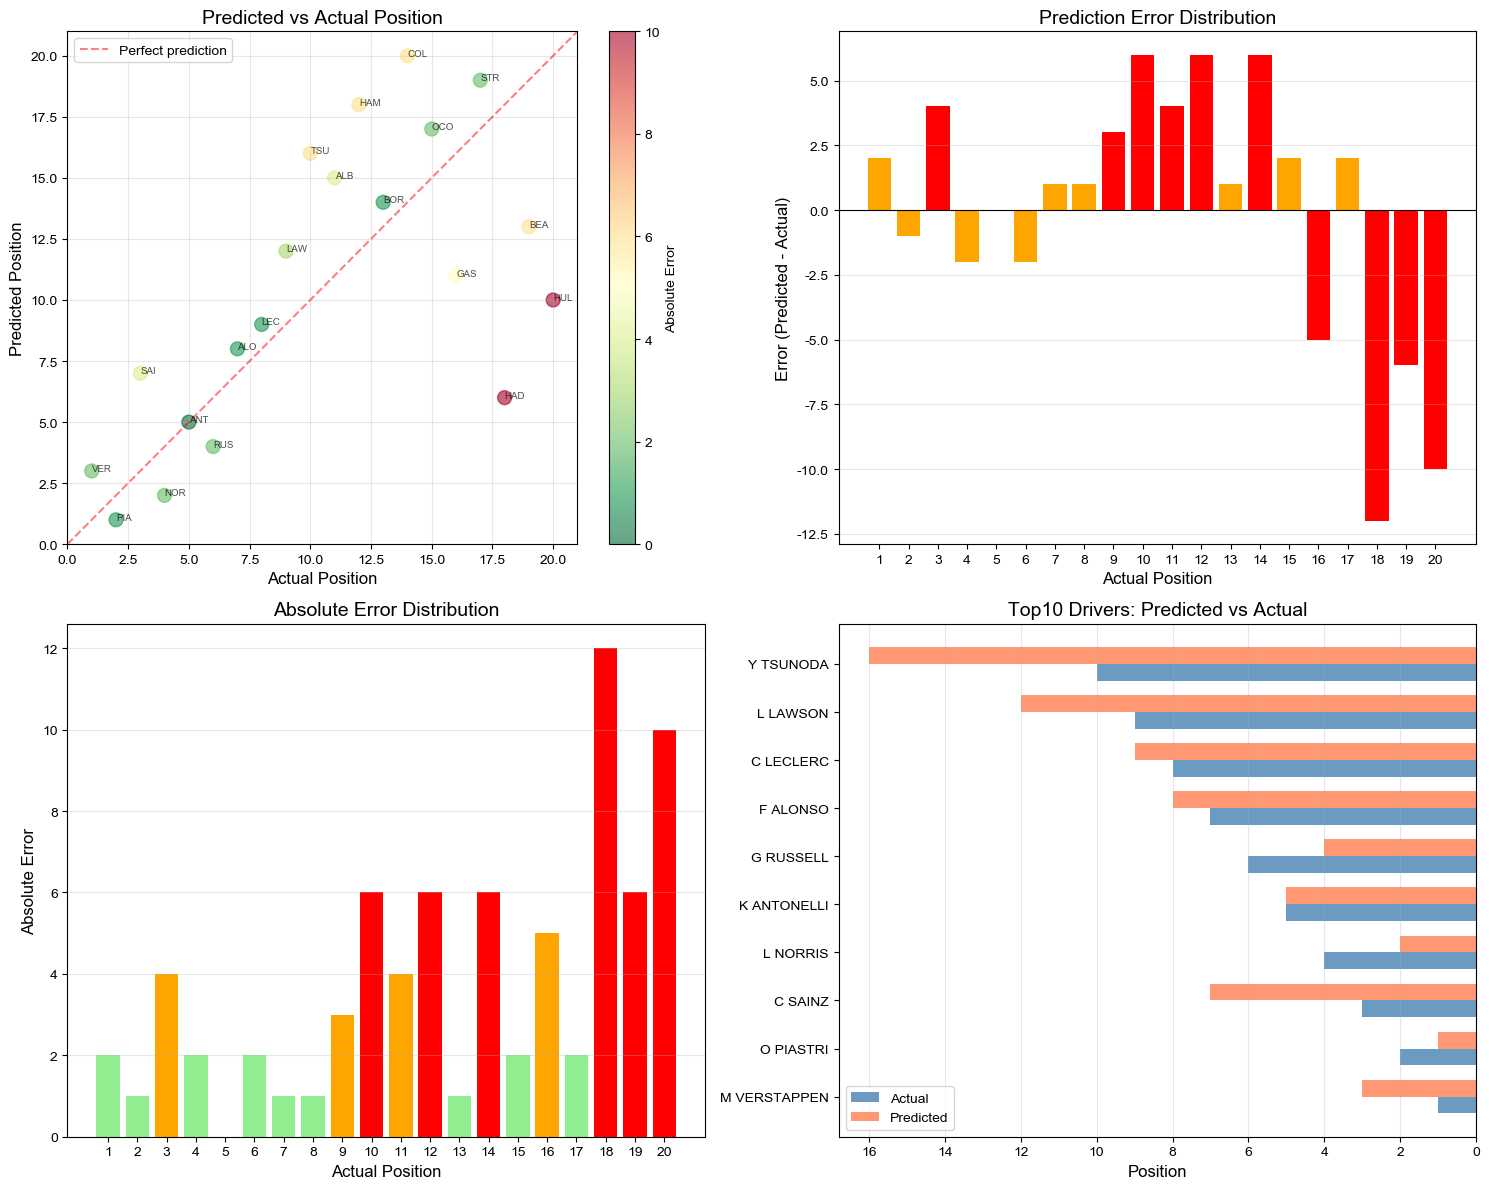

In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# Set font to support Chinese characters
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# Load predictions
predictions = pd.read_csv('./data/qatar_predict_menka.csv')

# Actual results
actual_results = {
    'Driver': ['M VERSTAPPEN', 'O PIASTRI', 'C SAINZ', 'L NORRIS', 'K ANTONELLI',
               'G RUSSELL', 'F ALONSO', 'C LECLERC', 'L LAWSON', 'Y TSUNODA',
               'A ALBON', 'L HAMILTON', 'G BORTOLETO', 'F COLAPINTO', 'E OCON',
               'P GASLY', 'L STROLL', 'I HADJAR', 'O BEARMAN', 'N HULKENBERG'],
    'ActualPosition': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
}
actual_df = pd.DataFrame(actual_results)

# Merge predictions with actual results
comparison = predictions.merge(actual_df, on='Driver', how='left')

# Calculate errors
comparison['Error'] = comparison['PredictedRank'] - comparison['ActualPosition']
comparison['AbsError'] = np.abs(comparison['Error'])

# Sort by actual position
comparison_sorted = comparison.sort_values('ActualPosition')

print("="*100)
print("Qatar Grand Prix - Prediction Evaluation")
print("="*100)

# ===========================
# 1. Overall Accuracy Metrics
# ===========================
print("\n[Overall Accuracy Metrics]")
print("-"*100)

mae = mean_absolute_error(comparison['ActualPosition'], comparison['PredictedRank'])
rmse = np.sqrt(mean_squared_error(comparison['ActualPosition'], comparison['PredictedRank']))
max_error = comparison['AbsError'].max()

print(f"MAE (Mean Absolute Error):    {mae:.2f} positions")
print(f"RMSE (Root Mean Squared):     {rmse:.2f} positions")
print(f"Maximum Error:                {max_error:.0f} positions")

# Spearman correlation
from scipy.stats import spearmanr
corr, p_value = spearmanr(comparison['ActualPosition'], comparison['PredictedRank'])
print(f"Spearman Correlation:         {corr:.3f}")

# ===========================
# 2. Stratified Accuracy
# ===========================
print("\n[Stratified Accuracy]")
print("-"*100)

# Top1
top1_predicted = comparison[comparison['PredictedRank'] == 1]['Driver'].values[0]
top1_actual = comparison[comparison['ActualPosition'] == 1]['Driver'].values[0]
top1_correct = top1_predicted == top1_actual
print(f"Winner Prediction: {'CORRECT' if top1_correct else 'INCORRECT'}")
print(f"  Predicted: {top1_predicted}")
print(f"  Actual:    {top1_actual}")

# Top3
predicted_top3 = set(comparison[comparison['PredictedRank'] <= 3]['Driver'])
actual_top3 = set(comparison[comparison['ActualPosition'] <= 3]['Driver'])
top3_hits = len(predicted_top3 & actual_top3)
print(f"\nPodium (Top3) Hits: {top3_hits}/3")
print(f"  Predicted: {sorted(predicted_top3)}")
print(f"  Actual:    {sorted(actual_top3)}")

# Top5
predicted_top5 = set(comparison[comparison['PredictedRank'] <= 5]['Driver'])
actual_top5 = set(comparison[comparison['ActualPosition'] <= 5]['Driver'])
top5_hits = len(predicted_top5 & actual_top5)
print(f"\nTop5 Hits: {top5_hits}/5 ({top5_hits/5:.1%})")

# Top10
predicted_top10 = set(comparison[comparison['PredictedRank'] <= 10]['Driver'])
actual_top10 = set(comparison[comparison['ActualPosition'] <= 10]['Driver'])
top10_hits = len(predicted_top10 & actual_top10)
print(f"Top10 Hits: {top10_hits}/10 ({top10_hits/10:.1%})")

# Stratified MAE
top5_df = comparison[comparison['ActualPosition'] <= 5]
top10_df = comparison[comparison['ActualPosition'] <= 10]
mae_top5 = mean_absolute_error(top5_df['ActualPosition'], top5_df['PredictedRank'])
mae_top10 = mean_absolute_error(top10_df['ActualPosition'], top10_df['PredictedRank'])

print(f"\nMAE (Top5):  {mae_top5:.2f} positions")
print(f"MAE (Top10): {mae_top10:.2f} positions")

# ===========================
# 3. Detailed Comparison Table
# ===========================
print("\n[Detailed Comparison]")
print("-"*100)

display_cols = ['ActualPosition', 'Driver', 'PredictedRank', 'Mode', 'Mean', 
                'P_Win', 'P_Top3', 'Error', 'AbsError']
display_df = comparison_sorted[display_cols].copy()

# Format percentages
display_df['P_Win'] = display_df['P_Win'].apply(lambda x: f"{x:.1%}")
display_df['P_Top3'] = display_df['P_Top3'].apply(lambda x: f"{x:.1%}")
display_df['Mean'] = display_df['Mean'].apply(lambda x: f"{x:.2f}")

# Add evaluation
def format_error(row):
    if row['AbsError'] == 0:
        return 'Perfect'
    elif row['AbsError'] <= 2:
        return f"Close ({row['Error']:+d})"
    elif row['AbsError'] <= 5:
        return f"Fair ({row['Error']:+d})"
    else:
        return f"Off ({row['Error']:+d})"

display_df['Evaluation'] = display_df.apply(format_error, axis=1)

print(display_df[['ActualPosition', 'Driver', 'PredictedRank', 'Mode', 
                  'Mean', 'P_Win', 'P_Top3', 'Evaluation']].to_string(index=False))

# ===========================
# 4. Biggest Deviations Analysis
# ===========================
print("\n[Biggest Deviations]")
print("-"*100)

worst_predictions = comparison_sorted.nlargest(5, 'AbsError')[
    ['Driver', 'ActualPosition', 'PredictedRank', 'Error', 'Mode', 'Mean']
]
print("\nTop 5 Largest Prediction Errors:")
print(worst_predictions.to_string(index=False))

best_predictions = comparison_sorted[comparison_sorted['AbsError'] <= 2][
    ['Driver', 'ActualPosition', 'PredictedRank', 'Error']
]
print(f"\nDrivers with Error <= 2 positions ({len(best_predictions)}/20):")
print(best_predictions.to_string(index=False))

# ===========================
# 5. Visualization
# ===========================
print("\n[Generating Visualizations]")
print("-"*100)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Predicted vs Actual scatter
ax1 = axes[0, 0]
scatter = ax1.scatter(comparison['ActualPosition'], comparison['PredictedRank'], 
           s=100, alpha=0.6, c=comparison['AbsError'], cmap='RdYlGn_r', vmin=0, vmax=10)
ax1.plot([0, 21], [0, 21], 'r--', alpha=0.5, label='Perfect prediction')
ax1.set_xlabel('Actual Position', fontsize=12)
ax1.set_ylabel('Predicted Position', fontsize=12)
ax1.set_title('Predicted vs Actual Position', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_xlim(0, 21)
ax1.set_ylim(0, 21)
plt.colorbar(scatter, ax=ax1, label='Absolute Error')

# Add driver labels
for _, row in comparison.iterrows():
    ax1.annotate(row['Driver'].split()[-1][:3], 
                (row['ActualPosition'], row['PredictedRank']),
                fontsize=7, alpha=0.7)

# Plot 2: Error distribution
ax2 = axes[0, 1]
colors = ['green' if e == 0 else 'orange' if abs(e) <= 2 else 'red' 
          for e in comparison_sorted['Error']]
ax2.bar(range(1, 21), comparison_sorted['Error'], color=colors)
ax2.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax2.set_xlabel('Actual Position', fontsize=12)
ax2.set_ylabel('Error (Predicted - Actual)', fontsize=12)
ax2.set_title('Prediction Error Distribution', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticks(range(1, 21))

# Plot 3: Absolute error
ax3 = axes[1, 0]
colors = ['green' if e == 0 else 'lightgreen' if e <= 2 else 'orange' if e <= 5 else 'red' 
          for e in comparison_sorted['AbsError']]
ax3.bar(range(1, 21), comparison_sorted['AbsError'], color=colors)
ax3.set_xlabel('Actual Position', fontsize=12)
ax3.set_ylabel('Absolute Error', fontsize=12)
ax3.set_title('Absolute Error Distribution', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_xticks(range(1, 21))

# Plot 4: Top10 comparison
ax4 = axes[1, 1]
top10_comparison = comparison_sorted.head(10)
x = np.arange(len(top10_comparison))
width = 0.35

bars1 = ax4.barh(x - width/2, top10_comparison['ActualPosition'], width, 
                label='Actual', color='steelblue', alpha=0.8)
bars2 = ax4.barh(x + width/2, top10_comparison['PredictedRank'], width,
                label='Predicted', color='coral', alpha=0.8)

ax4.set_yticks(x)
ax4.set_yticklabels(top10_comparison['Driver'])
ax4.set_xlabel('Position', fontsize=12)
ax4.set_title('Top10 Drivers: Predicted vs Actual', fontsize=14, fontweight='bold')
ax4.legend()
ax4.invert_xaxis()
ax4.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('data/qatar_prediction_evaluation.png', dpi=300, bbox_inches='tight')
print("Chart saved to: data/qatar_prediction_evaluation.png")

# ===========================
# 6. Quality Score
# ===========================
print("\n" + "="*100)
print("[Prediction Quality Score]")
print("="*100)

# Scoring system
score = 0
max_score = 100

# Winner prediction (20 points)
if top1_correct:
    score += 20
    print("Winner Prediction Correct:    +20 points")
else:
    print("Winner Prediction Incorrect:   0 points")

# Top3 hit rate (30 points)
top3_score = (top3_hits / 3) * 30
score += top3_score
print(f"Top3 Hits {top3_hits}/3:               +{top3_score:.0f} points")

# Top10 hit rate (30 points)
top10_score = (top10_hits / 10) * 30
score += top10_score
print(f"Top10 Hits {top10_hits}/10:            +{top10_score:.0f} points")

# MAE bonus (20 points)
if mae <= 2:
    mae_score = 20
elif mae <= 3:
    mae_score = 15
elif mae <= 4:
    mae_score = 10
elif mae <= 5:
    mae_score = 5
else:
    mae_score = 0
score += mae_score
print(f"MAE {mae:.2f}:                    +{mae_score:.0f} points")

print("\n" + "-"*100)
print(f"Total Score: {score:.0f}/{max_score} points")

if score >= 90:
    grade = "A+ Excellent"
elif score >= 80:
    grade = "A  Very Good"
elif score >= 70:
    grade = "B+ Good"
elif score >= 60:
    grade = "B  Fair"
else:
    grade = "C  Needs Improvement"

print(f"Grade: {grade}")
print("="*100)

# Save detailed results
comparison_sorted.to_csv('data/qatar_prediction_comparison.csv', index=False)
print("\nDetailed comparison saved to: data/qatar_prediction_comparison.csv")

QATAR GRAND PRIX - MULTI-STRATEGY PREDICTION EVALUATION

Strategy: BALANCED STRATEGY

[Overall Metrics]
  MAE:                3.80 positions
  RMSE:               4.85 positions
  Max Error:          12 positions
  Spearman Corr:      0.647

[Hit Rates]
  Winner:             INCORRECT (O PIASTRI)
  Top3 Hits:          2/3 (66.7%)
  Top5 Hits:          4/5 (80.0%)
  Top10 Hits:         8/10 (80.0%)

[Stratified MAE]
  MAE (Top5):         1.80 positions
  MAE (Top10):        2.20 positions

[Quality Score]
  Total Score:        54/100

Strategy: WINNER-FOCUSED

[Overall Metrics]
  MAE:                3.80 positions
  RMSE:               4.85 positions
  Max Error:          12 positions
  Spearman Corr:      0.647

[Hit Rates]
  Winner:             INCORRECT (O PIASTRI)
  Top3 Hits:          2/3 (66.7%)
  Top5 Hits:          4/5 (80.0%)
  Top10 Hits:         8/10 (80.0%)

[Stratified MAE]
  MAE (Top5):         1.80 positions
  MAE (Top10):        2.20 positions

[Quality Score]
  Total Sc

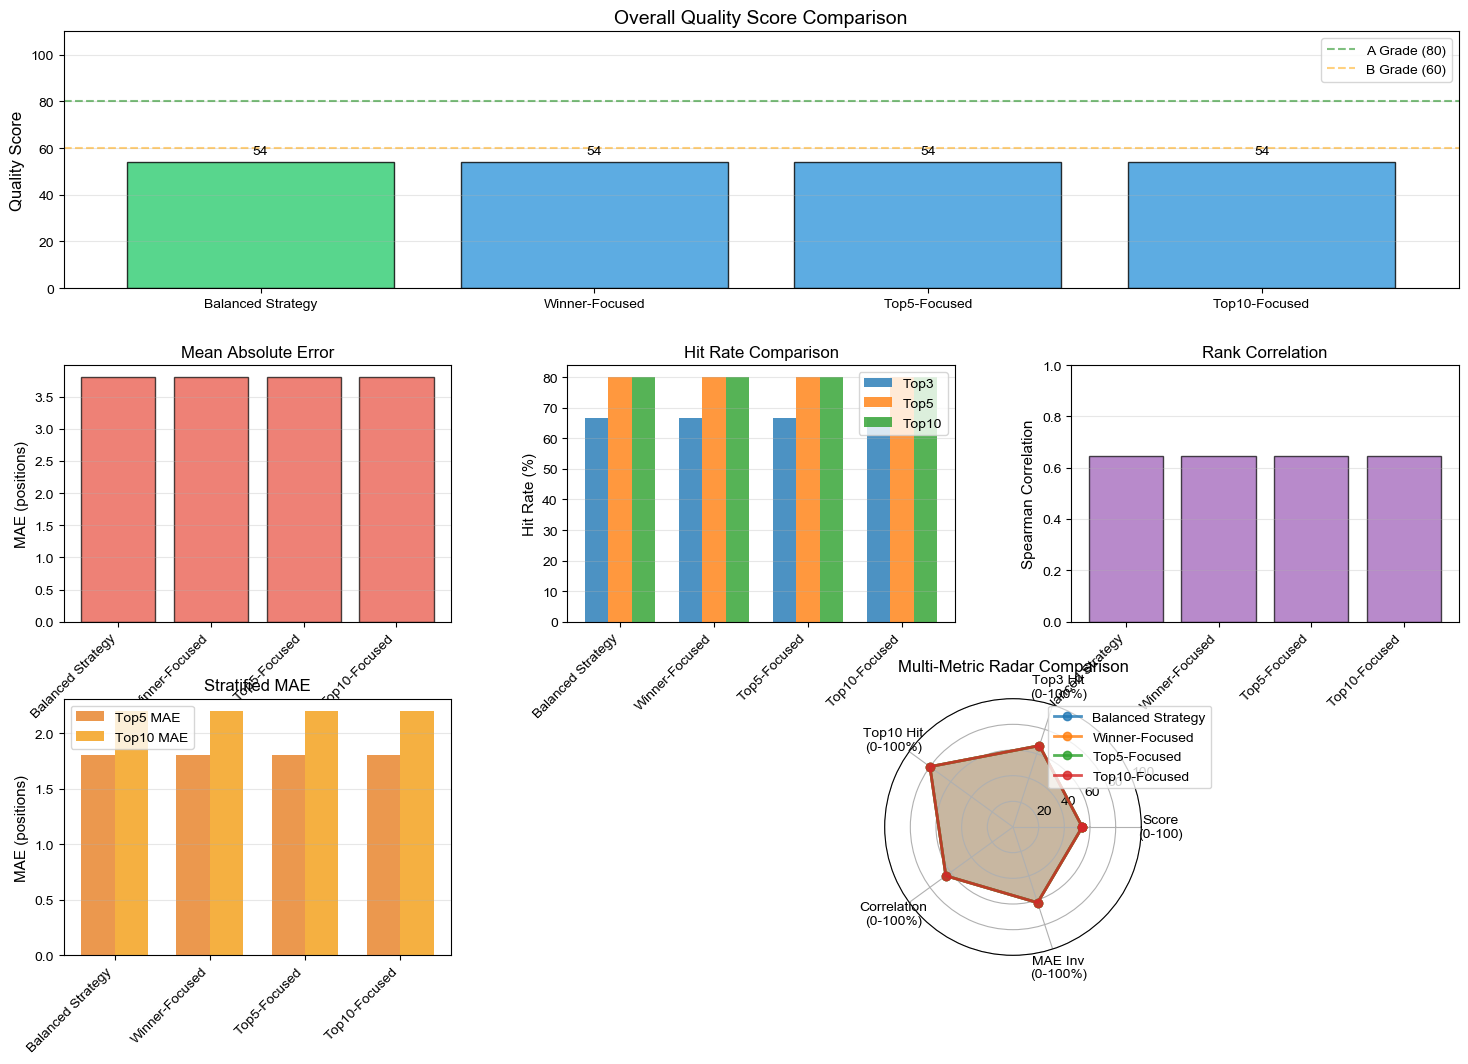

In [5]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Set font
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ===========================
# Load actual results
# ===========================
actual_results = {
    'Driver': ['M VERSTAPPEN', 'O PIASTRI', 'C SAINZ', 'L NORRIS', 'K ANTONELLI',
               'G RUSSELL', 'F ALONSO', 'C LECLERC', 'L LAWSON', 'Y TSUNODA',
               'A ALBON', 'L HAMILTON', 'G BORTOLETO', 'F COLAPINTO', 'E OCON',
               'P GASLY', 'L STROLL', 'I HADJAR', 'O BEARMAN', 'N HULKENBERG'],
    'ActualPosition': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
}
actual_df = pd.DataFrame(actual_results)

# ===========================
# Define strategies to compare
# ===========================
strategies = {
    'balanced': 'Balanced Strategy',
    'top1': 'Winner-Focused',
    'top5': 'Top5-Focused',
    'top10': 'Top10-Focused'
}

# ===========================
# Evaluate each strategy
# ===========================
print("="*120)
print("QATAR GRAND PRIX - MULTI-STRATEGY PREDICTION EVALUATION")
print("="*120)

results_summary = []

for strategy_key, strategy_name in strategies.items():
    print(f"\n{'='*120}")
    print(f"Strategy: {strategy_name.upper()}")
    print(f"{'='*120}")
    
    # Load predictions for this strategy
    pred_file = f'./data/qatar_final_prediction_{strategy_key}.csv'
    
    try:
        predictions = pd.read_csv(pred_file)
    except FileNotFoundError:
        print(f"  File not found: {pred_file}")
        print(f"  Skipping {strategy_name}...")
        continue
    
    # Merge with actual results
    comparison = predictions.merge(actual_df, on='Driver', how='left')
    comparison['Error'] = comparison['PredictedRank'] - comparison['ActualPosition']
    comparison['AbsError'] = np.abs(comparison['Error'])
    comparison_sorted = comparison.sort_values('ActualPosition')
    
    # Calculate metrics
    mae = mean_absolute_error(comparison['ActualPosition'], comparison['PredictedRank'])
    rmse = np.sqrt(mean_squared_error(comparison['ActualPosition'], comparison['PredictedRank']))
    max_error = comparison['AbsError'].max()
    corr, _ = spearmanr(comparison['ActualPosition'], comparison['PredictedRank'])
    
    # Top1
    top1_predicted = comparison[comparison['PredictedRank'] == 1]['Driver'].values[0]
    top1_actual = actual_df[actual_df['ActualPosition'] == 1]['Driver'].values[0]
    top1_correct = (top1_predicted == top1_actual)
    
    # Top3
    predicted_top3 = set(comparison[comparison['PredictedRank'] <= 3]['Driver'])
    actual_top3 = set(comparison[comparison['ActualPosition'] <= 3]['Driver'])
    top3_hits = len(predicted_top3 & actual_top3)
    
    # Top5
    predicted_top5 = set(comparison[comparison['PredictedRank'] <= 5]['Driver'])
    actual_top5 = set(comparison[comparison['ActualPosition'] <= 5]['Driver'])
    top5_hits = len(predicted_top5 & actual_top5)
    
    # Top10
    predicted_top10 = set(comparison[comparison['PredictedRank'] <= 10]['Driver'])
    actual_top10 = set(comparison[comparison['ActualPosition'] <= 10]['Driver'])
    top10_hits = len(predicted_top10 & actual_top10)
    
    # Stratified MAE
    top5_df = comparison[comparison['ActualPosition'] <= 5]
    top10_df = comparison[comparison['ActualPosition'] <= 10]
    mae_top5 = mean_absolute_error(top5_df['ActualPosition'], top5_df['PredictedRank'])
    mae_top10 = mean_absolute_error(top10_df['ActualPosition'], top10_df['PredictedRank'])
    
    # Calculate score
    score = 0
    if top1_correct:
        score += 20
    score += (top3_hits / 3) * 30
    score += (top10_hits / 10) * 30
    if mae <= 2:
        score += 20
    elif mae <= 3:
        score += 15
    elif mae <= 4:
        score += 10
    elif mae <= 5:
        score += 5
    
    # Print results
    print(f"\n[Overall Metrics]")
    print(f"  MAE:                {mae:.2f} positions")
    print(f"  RMSE:               {rmse:.2f} positions")
    print(f"  Max Error:          {max_error:.0f} positions")
    print(f"  Spearman Corr:      {corr:.3f}")
    
    print(f"\n[Hit Rates]")
    print(f"  Winner:             {'CORRECT' if top1_correct else 'INCORRECT'} ({top1_predicted})")
    print(f"  Top3 Hits:          {top3_hits}/3 ({top3_hits/3:.1%})")
    print(f"  Top5 Hits:          {top5_hits}/5 ({top5_hits/5:.1%})")
    print(f"  Top10 Hits:         {top10_hits}/10 ({top10_hits/10:.1%})")
    
    print(f"\n[Stratified MAE]")
    print(f"  MAE (Top5):         {mae_top5:.2f} positions")
    print(f"  MAE (Top10):        {mae_top10:.2f} positions")
    
    print(f"\n[Quality Score]")
    print(f"  Total Score:        {score:.0f}/100")
    
    # Store results
    results_summary.append({
        'Strategy': strategy_name,
        'Strategy_Key': strategy_key,
        'MAE': mae,
        'RMSE': rmse,
        'Max_Error': max_error,
        'Spearman': corr,
        'Winner_Correct': top1_correct,
        'Top3_Hits': top3_hits,
        'Top5_Hits': top5_hits,
        'Top10_Hits': top10_hits,
        'MAE_Top5': mae_top5,
        'MAE_Top10': mae_top10,
        'Score': score
    })

# ===========================
# Summary comparison
# ===========================
if not results_summary:
    print("\n❌ No prediction files found. Please run the optimization workflow first.")
    exit()

summary_df = pd.DataFrame(results_summary)

print("\n" + "="*120)
print("STRATEGY COMPARISON SUMMARY")
print("="*120)

# Create comparison table
comparison_table = summary_df[[
    'Strategy', 'Score', 'MAE', 'Winner_Correct', 
    'Top3_Hits', 'Top10_Hits', 'Spearman'
]].copy()

comparison_table['Winner_Correct'] = comparison_table['Winner_Correct'].map({True: 'YES', False: 'NO'})
comparison_table['Top3_Rate'] = summary_df['Top3_Hits'].apply(lambda x: f"{x}/3")
comparison_table['Top10_Rate'] = summary_df['Top10_Hits'].apply(lambda x: f"{x}/10")

print("\n")
print(comparison_table.to_string(index=False))

# Find best strategy
best_strategy_idx = summary_df['Score'].idxmax()
best_strategy = summary_df.loc[best_strategy_idx]

print("\n" + "-"*120)
print(f"BEST STRATEGY: {best_strategy['Strategy'].upper()}")
print(f"  Score: {best_strategy['Score']:.0f}/100")
print(f"  MAE: {best_strategy['MAE']:.2f}")
print(f"  Top3 Hits: {best_strategy['Top3_Hits']}/3")
print(f"  Top10 Hits: {best_strategy['Top10_Hits']}/10")
print("-"*120)

# ===========================
# Visualization
# ===========================
print("\n[Generating Comparison Charts]")

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Overall Score Comparison
ax1 = fig.add_subplot(gs[0, :])
colors = ['#2ecc71' if i == best_strategy_idx else '#3498db' for i in range(len(summary_df))]
bars = ax1.bar(summary_df['Strategy'], summary_df['Score'], color=colors, alpha=0.8, edgecolor='black')
ax1.axhline(80, color='green', linestyle='--', alpha=0.5, label='A Grade (80)')
ax1.axhline(60, color='orange', linestyle='--', alpha=0.5, label='B Grade (60)')
ax1.set_ylabel('Quality Score', fontsize=12, fontweight='bold')
ax1.set_title('Overall Quality Score Comparison', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 110)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{height:.0f}', ha='center', va='bottom', fontweight='bold')

# 2. MAE Comparison
ax2 = fig.add_subplot(gs[1, 0])
ax2.bar(summary_df['Strategy'], summary_df['MAE'], color='#e74c3c', alpha=0.7, edgecolor='black')
ax2.set_ylabel('MAE (positions)', fontsize=11)
ax2.set_title('Mean Absolute Error', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 3. Hit Rate Comparison
ax3 = fig.add_subplot(gs[1, 1])
x = np.arange(len(summary_df))
width = 0.25
ax3.bar(x - width, summary_df['Top3_Hits']/3*100, width, label='Top3', alpha=0.8)
ax3.bar(x, summary_df['Top5_Hits']/5*100, width, label='Top5', alpha=0.8)
ax3.bar(x + width, summary_df['Top10_Hits']/10*100, width, label='Top10', alpha=0.8)
ax3.set_ylabel('Hit Rate (%)', fontsize=11)
ax3.set_title('Hit Rate Comparison', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(summary_df['Strategy'])
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 4. Spearman Correlation
ax4 = fig.add_subplot(gs[1, 2])
ax4.bar(summary_df['Strategy'], summary_df['Spearman'], color='#9b59b6', alpha=0.7, edgecolor='black')
ax4.set_ylabel('Spearman Correlation', fontsize=11)
ax4.set_title('Rank Correlation', fontsize=12, fontweight='bold')
ax4.set_ylim(0, 1)
ax4.grid(True, alpha=0.3, axis='y')
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 5. Stratified MAE
ax5 = fig.add_subplot(gs[2, 0])
x = np.arange(len(summary_df))
width = 0.35
ax5.bar(x - width/2, summary_df['MAE_Top5'], width, label='Top5 MAE', alpha=0.8, color='#e67e22')
ax5.bar(x + width/2, summary_df['MAE_Top10'], width, label='Top10 MAE', alpha=0.8, color='#f39c12')
ax5.set_ylabel('MAE (positions)', fontsize=11)
ax5.set_title('Stratified MAE', fontsize=12, fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(summary_df['Strategy'])
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 6. Radar Chart
ax6 = fig.add_subplot(gs[2, 1:], projection='polar')

categories = ['Score\n(0-100)', 'Top3 Hit\n(0-100%)', 'Top10 Hit\n(0-100%)', 
              'Correlation\n(0-100%)', 'MAE Inv\n(0-100%)']
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

for idx, row in summary_df.iterrows():
    values = [
        row['Score'],
        row['Top3_Hits']/3*100,
        row['Top10_Hits']/10*100,
        row['Spearman']*100,
        max(0, (10 - row['MAE'])/10*100)  # Inverse MAE (lower is better)
    ]
    values += values[:1]
    
    ax6.plot(angles, values, 'o-', linewidth=2, label=row['Strategy'], alpha=0.8)
    ax6.fill(angles, values, alpha=0.15)

ax6.set_xticks(angles[:-1])
ax6.set_xticklabels(categories, size=10)
ax6.set_ylim(0, 100)
ax6.set_title('Multi-Metric Radar Comparison', fontsize=12, fontweight='bold', pad=20)
ax6.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax6.grid(True)

plt.savefig('data/strategy_comparison.png', dpi=300, bbox_inches='tight')
print("Chart saved to: data/strategy_comparison.png")

# ===========================
# Detailed comparison for each driver
# ===========================
print("\n[Generating Detailed Driver Comparison]")

# Load all predictions
all_predictions = {}
for strategy_key, strategy_name in strategies.items():
    pred_file = f'./data/qatar_final_prediction_{strategy_key}.csv'
    try:
        all_predictions[strategy_key] = pd.read_csv(pred_file)
    except FileNotFoundError:
        continue

if len(all_predictions) > 0:
    # Create comparison DataFrame
    driver_comparison = actual_df.copy()
    
    for strategy_key, pred_df in all_predictions.items():
        driver_comparison = driver_comparison.merge(
            pred_df[['Driver', 'PredictedRank']],
            on='Driver',
            how='left',
            suffixes=('', f'_{strategy_key}')
        )
        driver_comparison.rename(columns={'PredictedRank': f'Pred_{strategy_key}'}, inplace=True)
    
    # Calculate errors for each strategy
    for strategy_key in all_predictions.keys():
        driver_comparison[f'Error_{strategy_key}'] = (
            driver_comparison[f'Pred_{strategy_key}'] - driver_comparison['ActualPosition']
        )
        driver_comparison[f'AbsError_{strategy_key}'] = np.abs(driver_comparison[f'Error_{strategy_key}'])
    
    # Sort by actual position
    driver_comparison = driver_comparison.sort_values('ActualPosition')
    
    # Save detailed comparison
    driver_comparison.to_csv('data/driver_strategy_comparison.csv', index=False)
    print("Detailed driver comparison saved to: data/driver_strategy_comparison.csv")
    
    # Print top 10 comparison
    print("\n" + "="*120)
    print("TOP 10 DRIVERS - PREDICTION COMPARISON")
    print("="*120)
    
    display_cols = ['ActualPosition', 'Driver']
    for strategy_key in all_predictions.keys():
        display_cols.append(f'Pred_{strategy_key}')
    
    print(driver_comparison[display_cols].head(10).to_string(index=False))

print("\n" + "="*120)
print("EVALUATION COMPLETE")
print("="*120)

# Save summary
summary_df.to_csv('data/strategy_summary.csv', index=False)
print("\nSummary saved to: data/strategy_summary.csv")

In [6]:
import pandas as pd

# 1. 检查权重文件
print("="*80)
print("Checking Optimal Weights")
print("="*80)

try:
    weights_df = pd.read_csv('data/optimal_fusion_weights.csv', index_col=0)
    print(weights_df)
    
    # 计算权重差异
    print("\n权重差异分析:")
    for col in weights_df.columns:
        print(f"\n{col}:")
        print(weights_df[col])
        
except FileNotFoundError:
    print("❌ optimal_fusion_weights.csv not found!")
    print("   权重优化可能没有成功运行")

# 2. 检查历史预测数据
print("\n" + "="*80)
print("Checking Historical Predictions")
print("="*80)

try:
    historical = pd.read_csv('data/historical_predictions.csv')
    print(f"✓ 历史预测数据: {len(historical)} 条记录")
    print(f"✓ 涵盖比赛数: {historical['RaceName'].nunique()}")
    print(f"\n比赛列表:")
    print(historical.groupby('RaceName').size())
    
except FileNotFoundError:
    print("❌ historical_predictions.csv not found!")
    print("   需要先生成历史预测数据")

# 3. 对比不同策略的预测文件
print("\n" + "="*80)
print("Comparing Strategy Predictions")
print("="*80)

strategies = ['balanced', 'top1', 'top5', 'top10']

for strategy in strategies:
    try:
        df = pd.read_csv(f'data/qatar_final_prediction_{strategy}.csv')
        print(f"\n{strategy}:")
        print(df[['Driver', 'PredictedRank', 'Mode', 'Mean', 'P_Win']].head(5))
    except FileNotFoundError:
        print(f"❌ qatar_final_prediction_{strategy}.csv not found!")

Checking Optimal Weights
         balanced  top1  top5  top10
Mode         0.40  0.40  0.40   0.40
Mean         0.30  0.30  0.30   0.30
P_Win        0.20  0.20  0.20   0.20
Median       0.05  0.05  0.05   0.05
Entropy      0.05  0.05  0.05   0.05

权重差异分析:

balanced:
Mode       0.40
Mean       0.30
P_Win      0.20
Median     0.05
Entropy    0.05
Name: balanced, dtype: float64

top1:
Mode       0.40
Mean       0.30
P_Win      0.20
Median     0.05
Entropy    0.05
Name: top1, dtype: float64

top5:
Mode       0.40
Mean       0.30
P_Win      0.20
Median     0.05
Entropy    0.05
Name: top5, dtype: float64

top10:
Mode       0.40
Mean       0.30
P_Win      0.20
Median     0.05
Entropy    0.05
Name: top10, dtype: float64

Checking Historical Predictions
✓ 历史预测数据: 439 条记录
✓ 涵盖比赛数: 22

比赛列表:
RaceName
2025-03-16_Australian_Grand_Prix        20
2025-03-23_Chinese_Grand_Prix           20
2025-04-06_Japanese_Grand_Prix          20
2025-04-13_Bahrain_Grand_Prix           20
2025-04-20_Saudi_Arabian_Gr

Exception ignored in: <function ResourceTracker.__del__ at 0x104aedbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1071d1bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
